In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split


In [3]:
df = pd.read_excel("final.xlsx", sheet_name="Sheet1")

In [4]:
df.head()

,age,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,n_disease
0,25,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,Bronze,5684,0
1,20,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,Bronze,5712,0
2,19,Unmarried,0,Normal,No Smoking,Freelancer,<10L,8,Bronze,4097,0
3,23,Unmarried,0,Normal,No Smoking,Freelancer,25L - 40L,29,Bronze,7803,0
4,18,Unmarried,1,Normal,Occasional,Freelancer,<10L,8,Bronze,8111,2


In [7]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [8]:
df.head()

,age,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,n_disease
0,25,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,Bronze,5684,0
1,20,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,Bronze,5712,0
2,19,Unmarried,0,Normal,No Smoking,Freelancer,<10L,8,Bronze,4097,0
3,23,Unmarried,0,Normal,No Smoking,Freelancer,25L - 40L,29,Bronze,7803,0
4,18,Unmarried,1,Normal,Occasional,Freelancer,<10L,8,Bronze,8111,2


In [9]:
y = df['annual_premium_amount'].copy()
x = df.drop(['annual_premium_amount'], axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=2)

In [10]:
oe = OrdinalEncoder(
    categories=[
        ['Unmarried', 'Married'],       
        ['Underweight', 'Normal', 'Overweight', 'Obesity'],       
        ['No Smoking', 'Occasional', 'Regular'],
        ['Freelancer', 'Self-Employed', 'Salaried'],       
        ['<10L', '10L - 25L', '25L - 40L','> 40L'],       
        ['Bronze', 'Silver', 'Gold']       
    ]
)

In [11]:
df.columns

Index(['age', 'marital_status', 'number_of_dependants', 'bmi_category',
       'smoking_status', 'employment_status', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'n_disease'],
      dtype='object')

In [ ]:
#scaling not required
num_cols = [
    "age",
    'number_of_dependants',
    "income_lakhs",
    'n_disease'
]

# All remaining columns → ordinal
ordinal_col = [
    "marital_status",
    "bmi_category",
    "smoking_status",
    'employment_status',
    'income_level',
    "insurance_plan",
]


preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", oe, ordinal_col),
    ]
)

In [14]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", RandomForestRegressor())
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age',
                                                   'number_of_dependants',
                                                   'income_lakhs',
                                                   'n_disease']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Unmarried',
                                                                              'Married'],
                                                                             ['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obesity'],
                                                                             ['No '
                                                                              'Smoking',
                                                                              'Occasional',
                                                                              'Regular'],
                                                                             ['Freelancer',
                                                                              'Self-Employed',
                                                                              'Salaried'],
                                                                             ['<10L',
                                                                              '10L '
                                                                              '- '
                                                                              '25L',
                                                                              '25L '
                                                                              '- '
                                                                              '40L',
                                                                              '> '
                                                                              '40L'],
                                                                             ['Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['marital_status',
                                                   'bmi_category',
                                                   'smoking_status',
                                                   'employment_status',
                                                   'income_level',
                                                   'insurance_plan'])])),
                ('tree', RandomForestRegressor())])

In [15]:
# r2 score
model.score(x_test, y_test)

0.9648917702758399

In [16]:
model.score(x_train, y_train)

0.9924533139036835

let look at Feature importance 

In [20]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = model.named_steps["tree"].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances*100
})

# Sort
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

                     feature  importance
0                   num__age   59.071595
9        cat__insurance_plan   34.249714
5          cat__bmi_category    2.036167
6        cat__smoking_status    1.569600
3             num__n_disease    1.393966
2          num__income_lakhs    0.957361
1  num__number_of_dependants    0.332774
7     cat__employment_status    0.264517
8          cat__income_level    0.066148
4        cat__marital_status    0.058158


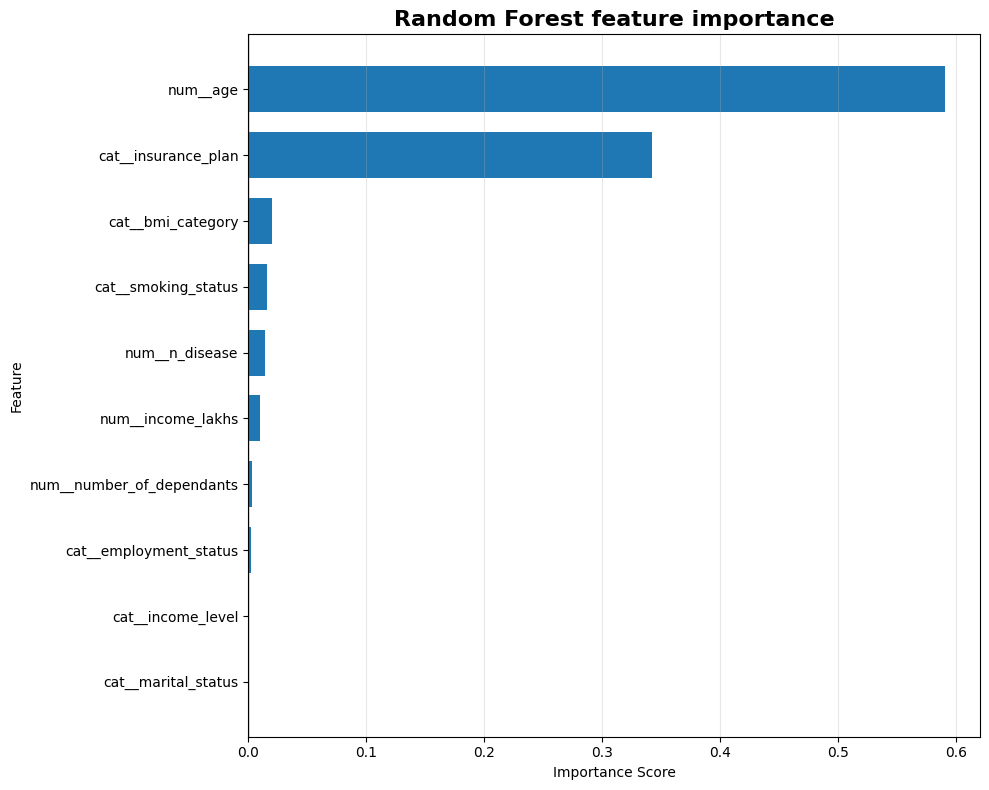

In [21]:
# Create DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": importances
})

# Sort coefficients
coef_df = coef_df.sort_values("Coefficient")

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    height=0.7
)

# Zero reference line
plt.axvline(0, linewidth=1)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest feature importance", fontsize=16, fontweight="bold")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

according to the Random Forest's impurity-based relative importance calculation,
these are the scores

conclusion:

age, insurance plan, bmi, smooking, disease are the important once
let see what happens if we only keep these ones

In [ ]:
oe = OrdinalEncoder(
    categories=[      
        ['Underweight', 'Normal', 'Overweight', 'Obesity'],       
        ['No Smoking', 'Occasional', 'Regular'],           
        ['Bronze', 'Silver', 'Gold']       
    ]
)

In [ ]:
#scaling not required
num_cols = [
    "age",
    # "income_lakhs",
    'diabetes',	
    'heart_disease',
    'high_blood_pressure',
    'thyroid',
    # 'income_bins',
    # 'age_bins'
]

# All remaining columns → ordinal
ordinal_col = [
    # "marital_status",
    "bmi_category",
    "smoking_status",
    "insurance_plan"
]

# nominal_col = ["employment_status"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", oe, ordinal_col)
        # ("nominal", OneHotEncoder(handle_unknown="ignore", drop = "first"), nominal_col)
    ]
)

In [ ]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", RandomForestRegressor(random_state=42))
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'diabetes',
                                                   'heart_disease',
                                                   'high_blood_pressure',
                                                   'thyroid']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obesity'],
                                                                             ['No '
                                                                              'Smoking',
                                                                              'Occasional',
                                                                              'Regular'],
                                                                             ['Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['bmi_category',
                                                   'smoking_status',
                                                   'insurance_plan'])])),
                ('tree', RandomForestRegressor(random_state=42))])

In [ ]:
# r2 score
model.score(x_train, y_train)

0.9834712928146032

In [ ]:
# r2 score
model.score(x_test, y_test)

0.9810044284136701

that's a noticable improvenment
and also the overfitting reduced 

In [ ]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = model.named_steps["tree"].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances*100
})

# Sort
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

                    feature  importance
0                  num__age   59.364483
7       cat__insurance_plan   34.662633
5         cat__bmi_category    2.025317
2        num__heart_disease    1.622999
6       cat__smoking_status    1.534349
4              num__thyroid    0.330794
3  num__high_blood_pressure    0.248445
1             num__diabetes    0.210980


lets try xgboost now

In [36]:
from xgboost import XGBRegressor

In [40]:
oe = OrdinalEncoder(
    categories=[
        ['Unmarried', 'Married'],       
        ['Underweight', 'Normal', 'Overweight', 'Obesity'],       
        ['No Smoking', 'Occasional', 'Regular'],
        ['Freelancer', 'Self-Employed', 'Salaried'],       
        ['<10L', '10L - 25L', '25L - 40L','> 40L'],       
        ['Bronze', 'Silver', 'Gold']      
    ]
)

In [41]:
#scaling not required
num_cols = [
    "age",
    'number_of_dependants',
    "income_lakhs",
    'n_disease'
]

# All remaining columns → ohe
ordinal_col = [
    "marital_status",
    "bmi_category",
    "smoking_status",
    'employment_status',
    'income_level',
    "insurance_plan",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", oe, ordinal_col)
    ]
)

In [42]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", XGBRegressor(random_state=42, n_estimators = 80, max_depth = 3))
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age',
                                                   'number_of_dependants',
                                                   'income_lakhs',
                                                   'n_disease']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Unmarried',
                                                                              'Married'],
                                                                             ['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obesity'],
                                                                             ['No '
                                                                              'Smoking',
                                                                              'Occasional',
                                                                              'Regular'],
                                                                             ['Freelancer',
                                                                              'Self-Employed',
                                                                              'Salaried'],
                                                                             ['<10L',
                                                                              '10L '
                                                                              '- '
                                                                              '25...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=80, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [43]:
# r2 score
print(model.score(x_train, y_train))

# r2 score
print(model.score(x_test, y_test))

0.9721397161483765
0.9716452360153198


In [45]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = model.named_steps["tree"].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances*100
})

# Sort
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

                     feature  importance
9        cat__insurance_plan   58.237873
0                   num__age   33.120602
3             num__n_disease    3.306490
6        cat__smoking_status    2.899385
5          cat__bmi_category    2.372427
4        cat__marital_status    0.016465
8          cat__income_level    0.013872
7     cat__employment_status    0.011104
2          num__income_lakhs    0.010970
1  num__number_of_dependants    0.010806


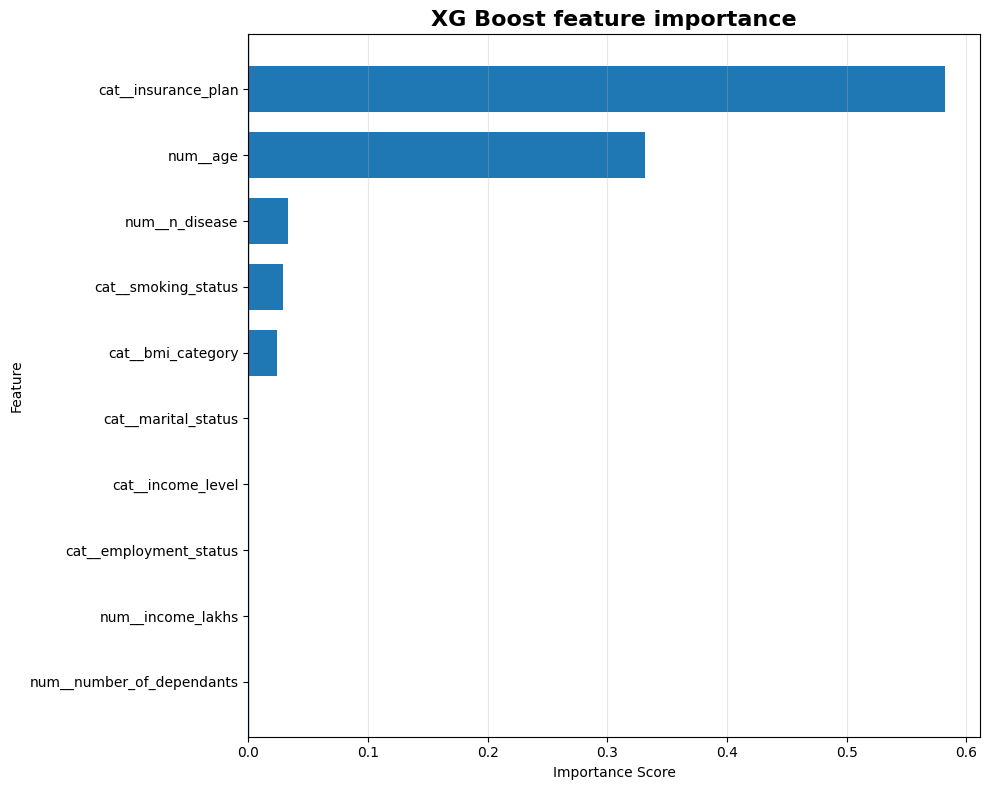

In [46]:
# Create DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": importances
})

# Sort coefficients
coef_df = coef_df.sort_values("Coefficient")

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    coef_df["Feature"],
    coef_df["Coefficient"],
    height=0.7
)

# Zero reference line
plt.axvline(0, linewidth=1)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("XG Boost feature importance", fontsize=16, fontweight="bold")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

verdict:

- here also age, insurance plan, bmi, smooking, disease are the important once
- let see what happens if we only keep these ones

In [48]:
oe = OrdinalEncoder(
    categories=[    
        ['Underweight', 'Normal', 'Overweight', 'Obesity'],       
        ['No Smoking', 'Occasional', 'Regular'],           
        ['Bronze', 'Silver', 'Gold']       
    ]
)

In [ ]:
#scaling not required
num_cols = [
    "age",
    # 'number_of_dependants',
    # "income_lakhs",
    'n_disease'
]

# All remaining columns → ohe
ordinal_col = [
    # "marital_status",
    "bmi_category",
    "smoking_status",
    # 'employment_status',
    # 'income_level',
    "insurance_plan",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", oe, ordinal_col)
    ]
)

In [50]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("tree", XGBRegressor(random_state=42, n_estimators = 100, max_depth = 4))
])

model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'n_disease']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obesity'],
                                                                             ['No '
                                                                              'Smoking',
                                                                              'Occasional',
                                                                              'Regular'],
                                                                             ['Bronze',
                                                                              'Silver',
                                                                              'Gold']]),
                                                  ['bmi_category',
                                                   'smoking_status',
                                                   'insurance_plan'])])),
                ('tree',
                 XGBRegressor(base_score=None, bo...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [51]:
# r2 score
print(model.score(x_train, y_train))

# r2 score
print(model.score(x_test, y_test))

0.972615122795105
0.9719701409339905


In [52]:
# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = model.named_steps["tree"].feature_importances_

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances*100
})

# Sort
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

               feature  importance
4  cat__insurance_plan   52.617622
0             num__age   39.009331
1       num__n_disease    3.057421
3  cat__smoking_status    2.844813
2    cat__bmi_category    2.470814


conclusion:

- slight improvenment with just few features

is just high r2 good enough to deploy a model ??

### error analysis

In [54]:
y_pred = model.predict(x_test)
residuals = y_pred - y_test
res_pct = residuals*100 / y_test

In [55]:
results = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'diff': residuals,
    'diff_pct': res_pct
    })

In [56]:
results

,actual,predicted,diff,diff_pct
23656,15331,14138.619141,-1192.380859,-7.777580
27442,28923,29194.494141,271.494141,0.938679
40162,16197,16951.826172,754.826172,4.660284
8459,7881,6550.747070,-1330.252930,-16.879240
8051,6143,6528.699707,385.699707,6.278686
...,...,...,...,...
11715,17049,13489.246094,-3559.753906,-20.879547
33646,13140,10243.417969,-2896.582031,-22.044003
11304,5817,6368.243164,551.243164,9.476417
35365,9230,10243.417969,1013.417969,10.979610


<Axes: xlabel='diff_pct', ylabel='Count'>

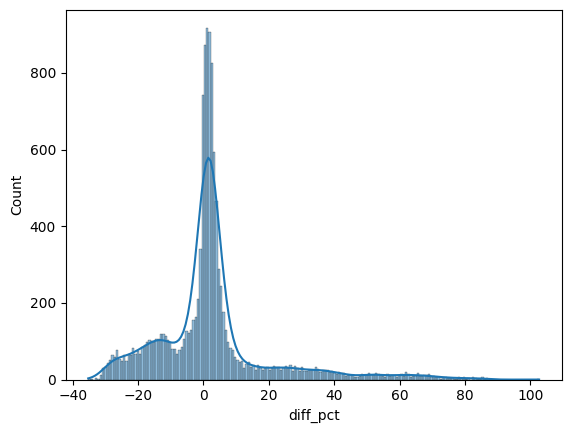

In [57]:
sns.histplot(results['diff_pct'], kde=True)

management says we should not have more than 10% error

In [59]:
th = 10
extreme_df = results[np.abs(results['diff_pct']) > th]
extreme_df

,actual,predicted,diff,diff_pct
8459,7881,6550.747070,-1330.252930,-16.879240
42404,8491,10139.316406,1648.316406,19.412512
89,5905,7594.236328,1689.236328,28.606881
1461,6293,8236.286133,1943.286133,30.880123
45479,11150,10017.838867,-1132.161133,-10.153912
...,...,...,...,...
6204,5816,7116.286621,1300.286621,22.357060
11715,17049,13489.246094,-3559.753906,-20.879547
33646,13140,10243.417969,-2896.582031,-22.044003
35365,9230,10243.417969,1013.417969,10.979610


In [60]:
# extreme error pct %
err_pct = len(extreme_df)*100 / len(results)
err_pct

34.016

In [61]:
results[np.abs(results['diff_pct']) > th].sort_values('diff_pct', ascending=False)

,actual,predicted,diff,diff_pct
20846,5708,11568.333008,5860.333008,102.668763
17669,3512,6563.845215,3051.845215,86.897643
7896,3508,6550.747070,3042.747070,86.737374
13181,3501,6534.614258,3033.614258,86.649936
1768,3517,6550.747070,3033.747070,86.259513
...,...,...,...,...
14032,9464,6368.243164,-3095.756836,-32.710871
2245,9487,6368.243164,-3118.756836,-32.874005
8011,9651,6475.032715,-3175.967285,-32.908168
6895,11333,7435.296387,-3897.703613,-34.392514


we need to find out where is this problem ?

-income group, age group, health, bmi ... etc

In [63]:
new = pd.concat([x_test, results], axis = 1)
new.head()

,age,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,n_disease,age_bins,income_bins,actual,predicted,diff,diff_pct
23656,22,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,100,Gold,1,1,3,15331,14138.619141,-1192.380859,-7.777580
27442,51,Unmarried,1,Normal,No Smoking,Salaried,> 40L,66,Gold,2,3,3,28923,29194.494141,271.494141,0.938679
40162,33,Unmarried,0,Normal,Occasional,Salaried,10L - 25L,10,Silver,1,2,1,16197,16951.826172,754.826172,4.660284
8459,24,Unmarried,1,Normal,No Smoking,Freelancer,> 40L,40,Bronze,0,1,2,7881,6550.747070,-1330.252930,-16.879240
8051,25,Unmarried,0,Normal,No Smoking,Freelancer,<10L,4,Bronze,0,1,1,6143,6528.699707,385.699707,6.278686


In [64]:
new.columns

Index(['age', 'marital_status', 'number_of_dependants', 'bmi_category',
       'smoking_status', 'employment_status', 'income_level', 'income_lakhs',
       'insurance_plan', 'n_disease', 'age_bins', 'income_bins', 'actual',
       'predicted', 'diff', 'diff_pct'],
      dtype='object')

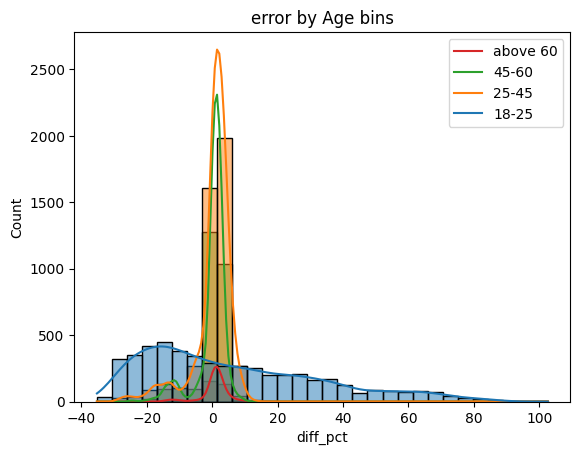

In [84]:
sns.histplot(data = new[['diff_pct', 'age_bins']], x = 'diff_pct', hue = 'age_bins', kde=True, bins = 30)
plt.title(f"error by Age bins")
plt.legend(["above 60", "45-60", "25-45", "18-25" ])
plt.show()

for age < 25 we have high variance in errors

In [120]:
extreme_error_df = df.loc[extreme_df.index]
extreme_error_df.head()

,age,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,insurance_plan,annual_premium_amount,n_disease,age_bins,income_bins
8459,24,Unmarried,1,Normal,No Smoking,Freelancer,40,Bronze,7881,0,1,2
42404,25,Unmarried,0,Underweight,No Smoking,Salaried,49,Silver,8491,0,1,3
89,23,Unmarried,0,Normal,Regular,Freelancer,6,Bronze,5905,1,1,1
1461,22,Unmarried,0,Obesity,Regular,Freelancer,17,Bronze,6293,1,1,2
45479,18,Unmarried,0,Normal,No Smoking,Self-Employed,30,Silver,11150,0,1,2


we will try:

model segmentation -> train separate model for high error groups (age > 25, bronze)

In [ ]:
df[df['age'] <= 25].to_excel("young.xlsx", index = False)
df[df['age'] > 25].to_excel("rest.xlsx", index = False)